# Description

Reads the aggregated prediction results from `021-prediction_performance.ipynb` and creates
ROC and precision-recall curve figures, following the same approach as PhenoPlier.

# Module loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
)

from pyprojroot import here

# Settings

In [3]:
PREDICTIONS_DIR = here('output/drug_disease_analyses') / 'predictions'
display(PREDICTIONS_DIR)
assert PREDICTIONS_DIR.exists()

OUTPUT_FIGURES_DIR = here('output/drug_disease_analyses') / 'figures'
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
display(OUTPUT_FIGURES_DIR)

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/drug_disease_analyses/predictions')

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/drug_disease_analyses/figures')

# Load predictions

In [4]:
predictions_avg = pd.read_pickle(PREDICTIONS_DIR / 'predictions_results_aggregated.pkl')
display(predictions_avg.shape)
display(predictions_avg.head())

(1370, 5)

,trait,drug,method,score,true_class
0,DOID:0050741,DB00215,Gene-based,294.2,1.0
1,DOID:0050741,DB00215,Module-based,313.8,1.0
2,DOID:0050741,DB00704,Gene-based,277.4,1.0
3,DOID:0050741,DB00704,Module-based,279.2,1.0
4,DOID:0050741,DB00822,Gene-based,536.6,1.0


# Rename methods

In [5]:
_method_rename = {
    'Module-based': 'LV-based',
}

predictions_avg = predictions_avg.replace({'method': _method_rename})
display(predictions_avg['method'].unique())

array(['Gene-based', 'LV-based'], dtype=object)

# Plot settings

In [6]:
methods_names = tuple(predictions_avg['method'].unique())
assert len(methods_names) == 2
display(methods_names)

methods_colors = {methods_names[0]: 'red', methods_names[1]: 'blue'}

('Gene-based', 'LV-based')

# ROC functions

In [7]:
def plot_roc(data, method_key, fig, ax):
    roc_auc = roc_auc_score(data['true_class'], data['score'])
    fpr, tpr, _ = roc_curve(data['true_class'], data['score'])

    label = f'{method_key} - AUC: {roc_auc:.3f}'
    sns.lineplot(
        x=fpr,
        y=tpr,
        estimator=None,
        label=label,
        ax=ax,
        linewidth=1.00,
        linestyle='-',
        color=methods_colors[method_key],
    )


def plot_roc_for_methods(selected_methods, fig, ax):
    for method_name in selected_methods:
        data = predictions_avg[predictions_avg['method'] == method_name]
        plot_roc(data, method_name, fig, ax)

    ax.plot([0.0, 1.00], [0.0, 1.00], color='gray', linewidth=1.25, linestyle='-')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim([0.0, 1.01])
    ax.set_ylim([0.0, 1.01])
    ax.set_aspect('equal')
    ax.legend(loc='lower right')

# PR functions

In [8]:
def plot_pr_raw_data(recall, precision, label, **kwargs):
    sns.lineplot(x=recall, y=precision, label=label, **kwargs)


def plot_pr(data, method_key, fig, ax):
    precision, recall, _ = precision_recall_curve(data['true_class'], data['score'])
    ap = average_precision_score(data['true_class'], data['score'])

    label = f'{method_key} - AP: {ap:.3f}'
    plot_pr_raw_data(
        recall,
        precision,
        label,
        estimator=None,
        ax=ax,
        linewidth=1.00,
        linestyle='-',
        color=methods_colors[method_key],
    )


def get_random_classifier_pr(data, reps=100):
    random_precision = []
    random_recall = []
    random_average_precision = []

    for _ in range(reps):
        random_score = np.random.permutation(data['score'].values)
        rp, rr, _ = precision_recall_curve(data['true_class'], random_score)
        random_precision.extend(rp)
        random_recall.extend(rr)
        random_average_precision.append(
            average_precision_score(data['true_class'], random_score)
        )

    return (
        np.array(random_recall),
        np.array(random_precision),
        np.array(random_average_precision),
    )


def plot_pr_for_methods(selected_methods, fig, ax):
    for method_name in selected_methods:
        data = predictions_avg[predictions_avg['method'] == method_name]
        plot_pr(data, method_name, fig, ax)

    # add random classifier
    random_recall, random_precision, random_averages = get_random_classifier_pr(data, reps=100)

    random_label = f'Random - AP: {random_averages.mean():.3f}'
    plot_pr_raw_data(
        random_recall,
        random_precision,
        random_label,
        estimator='mean',
        ax=ax,
        ci='sd',
        color='gray',
    )

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim([0.0, 1.01])
    ax.set_ylim([0.60, 1.02])
    ax.legend(loc='lower right')

# Combined ROC + PR plot

/tmp/ipykernel_1626909/8184949.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x=recall, y=precision, label=label, **kwargs)


PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/drug_disease_analyses/figures/roc_pr_curves.svg')

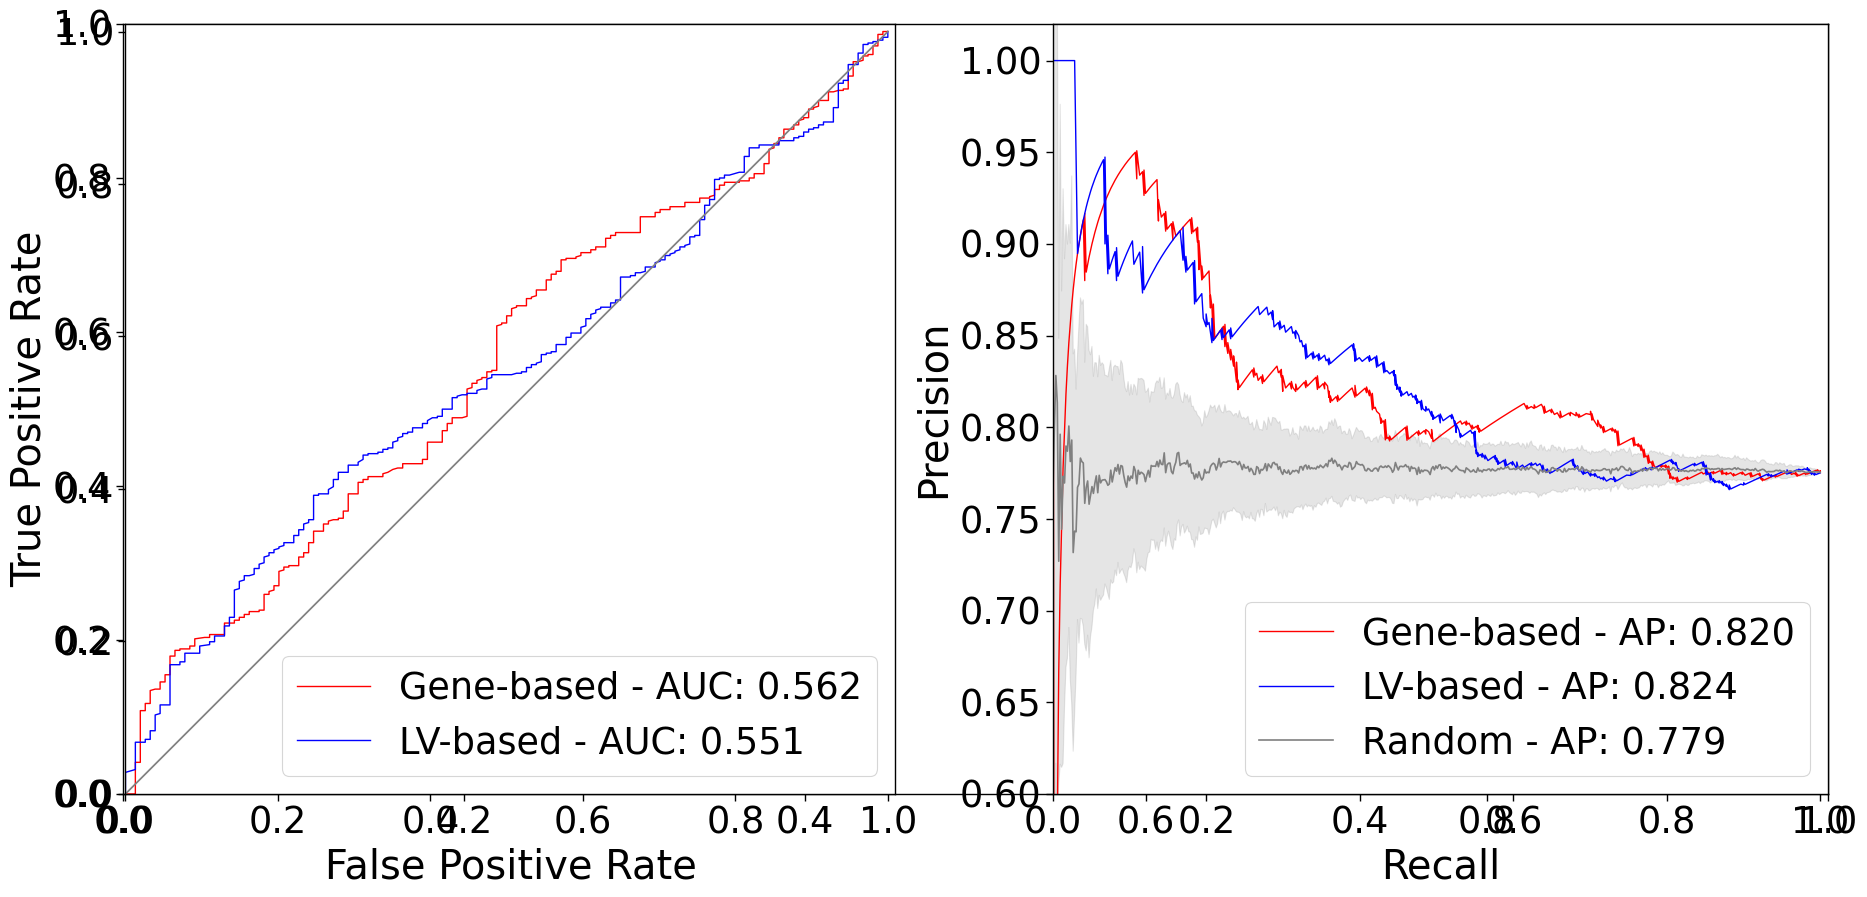

In [9]:
with sns.plotting_context('paper', font_scale=3.00):
    fig, ax = plt.subplots(figsize=(22, 10))

    ax = plt.subplot(1, 2, 1)
    plot_roc_for_methods(methods_names, fig, ax)

    ax = plt.subplot(1, 2, 2)
    plot_pr_for_methods(methods_names, fig, ax)

    output_filepath = OUTPUT_FIGURES_DIR / 'roc_pr_curves.svg'
    display(output_filepath)

    plt.savefig(
        output_filepath,
        bbox_inches='tight',
        facecolor='white',
    )